### Import Packages

In [1]:
! nvidia-smi

Tue Aug 12 20:00:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.15              Driver Version: 570.86.15      CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          Off |   00000000:25:00.0 Off |                    0 |
| N/A   28C    P0             33W /  250W |       1MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from keras.models import Model, load_model
from keras.layers import Input, LSTM, Dense, MultiHeadAttention, GlobalAveragePooling1D, Masking
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version: ", tf.__version__)
print("Number of GPUs available: ", len(tf.config.list_physical_devices('GPU')))

wind_MLP = load_model('wind_MLP.keras')

TensorFlow version:  2.19.0
Number of GPUs available:  1


### Data Preprocessing

In [4]:
cols = ['u','u_e','u_n']
scaled_cols = ['scaled_' + col for col in cols]

# Load datasets
df_buoy = pd.read_csv('WLIS_data.csv')
df_buoy = df_buoy.rename(columns={'WSPD':'u'})
df_buoy['TmStamp'] = pd.to_datetime(df_buoy['TmStamp'], format='mixed')
df_buoy.set_index('TmStamp', inplace=True)

df_stn = pd.read_csv('Sikorsky_data.csv')
df_stn = df_stn.rename(columns={'WSPD':'u'})
df_stn['TmStamp'] = pd.to_datetime(df_stn['TmStamp'], format='mixed')
df_stn.set_index('TmStamp', inplace=True)

# Add east and north components
alpha = -13
df_buoy['rad'] = np.pi/180 * ((alpha + 630 - df_buoy['WDIR']) % 360)
df_buoy['u_e'] = df_buoy['u'] * np.cos(df_buoy['rad'])
df_buoy['u_n'] = df_buoy['u'] * np.sin(df_buoy['rad'])

df_stn['rad'] = np.pi/180 * ((alpha + 630 - df_stn['WDIR']) % 360)
df_stn['u_e'] = df_stn['u'] * np.cos(df_stn['rad'])
df_stn['u_n'] = df_stn['u'] * np.sin(df_stn['rad'])

# Transform station wind into buoy wind
def wind_transform(df_stn):
    wind_T_uc = wind_MLP.predict(df_stn[cols[1:]], verbose=0)
    u_e, u_n = wind_T_uc[:, 0], wind_T_uc[:, 1]
    wind_T_u = np.sqrt(u_e**2 + u_n**2)
    df_T = pd.DataFrame({'u': wind_T_u, 'u_e': u_e, 'u_n': u_n})
    df_T.index = df_stn.index    
    return df_T

df_T = wind_transform(df_stn)

# df_test: [2024-07-01 00:00:00 ~ 2025-06-30 23:00:00]
split = pd.to_datetime('2024-06-30 23:59:00')
df_buoy_train = df_buoy[df_buoy.index < split]
df_buoy_test = df_buoy[df_buoy.index > split]
df_T_train = df_T[df_T.index < split]
df_T_test = df_T[df_T.index > split]

# Data normalization
scaled_wave, scaled_wind, scaled_T = MinMaxScaler(), MinMaxScaler(), MinMaxScaler()

df_buoy_train, df_buoy_test = df_buoy_train.copy(), df_buoy_test.copy()
df_buoy_train.loc[:, 'scaled_H'] = scaled_wave.fit_transform(df_buoy_train[['H']])
df_buoy_test.loc[:, 'scaled_H'] = scaled_wave.transform(df_buoy_test[['H']])
df_buoy_train.loc[:, scaled_cols] = scaled_wind.fit_transform(df_buoy_train[cols])
df_buoy_test.loc[:, scaled_cols] = scaled_wind.transform(df_buoy_test[cols])

df_T_train, df_T_test = df_T_train.copy(), df_T_test.copy()
df_T_train.loc[:, scaled_cols] = scaled_T.fit_transform(df_T_train[cols])
df_T_test.loc[:, scaled_cols] = scaled_T.transform(df_T_test[cols])

### Data Preparation: Train-Test-Validation Split

In [5]:
step, output = 24, 12
features = ['scaled_H'] + scaled_cols

def create_sequences(df_buoy, df_T, step, output):
    X, y = [], []
    periods = step + output
    for i in range(len(df_buoy) - periods + 1):
        window = df_buoy.iloc[i:(i+periods)]
        expect = pd.date_range(start=window.index[0], periods=periods, freq='h')
        if not window.index.equals(expect):
            continue
        X_seq = window.values.copy()
        X_seq[step:, 0] = -1
        X_seq[step:, 1:] = df_T.iloc[(i+step):(i+periods)].values
        X.append(X_seq)
        y.append(window.iloc[step:, 0].values)
    return np.array(X), np.array(y)

# Validation set: [2007-11-01 00:00:00 ~ 2008-10-31 23:00:00]
split1 = pd.to_datetime('2007-10-31 23:59:00')
split2 = pd.to_datetime('2008-10-31 23:59:00')
df_buoy_val = df_buoy_train[(df_buoy_train.index > split1) & (df_buoy_train.index < split2)]
df_buoy_train = df_buoy_train[(df_buoy_train.index < split1) | (df_buoy_train.index > split2)]
df_T_val = df_T_train[(df_T_train.index > split1) & (df_T_train.index < split2)]
df_T_train = df_T_train[(df_T_train.index < split1) | (df_T_train.index > split2)]

X_train, y_train = create_sequences(df_buoy_train[features], df_T_train[scaled_cols], step, output)
X_val, y_val = create_sequences(df_buoy_val[features], df_T_val[scaled_cols], step, output)
X_test, y_test = create_sequences(df_buoy_test[features], df_T_test[scaled_cols], step, output)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(105739, 36, 4) (105739, 12)
(8749, 36, 4) (8749, 12)
(8725, 36, 4) (8725, 12)


### Model Selection and Implementation

In [ ]:
epochs = 100
batch_size = 64
model_file = 'model_fcst.keras'

def create_model(X_train):
    # Input layer with shape: (batch_size, time_steps, features)
    input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

    # Masking layer
    mask_layer = Masking(-1)(input_layer)

    # LSTM layer
    units = 64
    lstm_layer = LSTM(units=256, activation='tanh', return_sequences=True)(mask_layer)
    lstm_out = LSTM(units=units, activation='tanh', return_sequences=True)(lstm_layer)
    
    # Attention layer
    num_heads = 4
    attn_layer = MultiHeadAttention(num_heads=num_heads, key_dim=units//num_heads)
    attn_out, attn_scores = attn_layer(lstm_out, lstm_out, return_attention_scores=True)
    
    # Pooling layer
    pooled_out = GlobalAveragePooling1D()(attn_out)

    # Output layer
    output_layer = Dense(12, activation='relu')(pooled_out)
    
    # Build model
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
    attn_model = Model(inputs=input_layer, outputs=attn_scores)
    
    return model, attn_model

# Train and save the model (architecture + weights)
model, attn_model = create_model(X_train)
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[es])
model.save(model_file)

# Plot the training & validation loss over epochs
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
head_idx = 0
attn_weights = attn_model.predict(X_test, verbose=0)
attn_head_matrix = attn_weights[:, head_idx, :, :]
attn_matrix = np.mean(attn_head_matrix, axis=0)

plt.figure(figsize=(6, 5))
sns.heatmap(attn_matrix, cmap='viridis')
plt.xlabel("Key Time Steps")
plt.ylabel("Query Time Steps")
plt.tight_layout()
plt.show()

### Model Evaluation

In [6]:
model_base = load_model('model_base.keras')

# Past 24h wind and wave features
def X_seq(df_buoy, step, output):
    X= []
    periods = step + output
    for i in range(len(df_buoy) - periods + 1):
        window = df_buoy.iloc[i:(i+periods)]
        expect = pd.date_range(start=window.index[0], periods=periods, freq='h')
        if not window.index.equals(expect):
            continue
        X.append(window.iloc[:step, :].values)
    return np.array(X)

# Test error
X_test1 = X_seq(df_buoy_test[features], step, output)
y_pred1 = model_base.predict(X_test1, verbose=0)
y_pred_raw1 = scaled_wave.inverse_transform(y_pred1)
y_true = scaled_wave.inverse_transform(y_test)
rmse_base = np.sqrt(mean_squared_error(y_true, y_pred_raw1))
print(f'Test RMSE: {rmse_base:.3f}')
rmse_arr1 = np.sqrt(mean_squared_error(y_true, y_pred_raw1, multioutput='raw_values'))
print('Test RMSE per output:', ', '.join([f'{rmse:.3f}' for rmse in rmse_arr1]))

Test RMSE: 0.520
Test RMSE per output: 0.247, 0.316, 0.385, 0.438, 0.487, 0.524, 0.558, 0.586, 0.607, 0.623, 0.636, 0.648


In [7]:
model_fcst = load_model('model_fcst.keras')

# Load dataset
df_fcst = pd.read_csv('Sikorsky_fcst.csv')
df_fcst = df_fcst.rename(columns={'WSPD':'u'})
df_fcst['TmStamp'] = pd.to_datetime(df_fcst['TmStamp'], format='mixed')
df_fcst.set_index('TmStamp', inplace=True)

# Wind transform & Data normalization
df_fcst_T = wind_transform(df_fcst)
df_fcst_T.loc[:, scaled_cols] = scaled_T.transform(df_fcst_T[cols])

# Test error
X_test2 = create_sequences(df_buoy_test[features], df_fcst_T[scaled_cols], step, output)[0]
y_pred2 = model_fcst.predict(X_test2, verbose=0)
y_pred_raw2 = scaled_wave.inverse_transform(y_pred2)
rmse_fcst = np.sqrt(mean_squared_error(y_true, y_pred_raw2))
print(f'Test RMSE: {rmse_fcst:.3f}')
rmse_arr2 = np.sqrt(mean_squared_error(y_true, y_pred_raw2, multioutput='raw_values'))
print('Test RMSE per output:', ', '.join([f'{rmse:.3f}' for rmse in rmse_arr2]))

Test RMSE: 0.428
Test RMSE per output: 0.239, 0.302, 0.373, 0.408, 0.438, 0.450, 0.468, 0.470, 0.477, 0.481, 0.473, 0.476


In [8]:
rho = 0.054

# Add future wind noise
def add_noise(df, abs_std, rel_std, random_seed=42):
    rng = np.random.default_rng(random_seed)
    wind = df[cols].to_numpy(dtype=float)
    stds = abs_std + rel_std * wind[:, 0]
    cov = np.array([[1, rho], [rho, 1]])
    L_cov = np.linalg.cholesky(cov)
    z = rng.normal(0, 1, size=(wind.shape[0], 2))
    noise = z @ L_cov.T * stds[:, None]
    nu_e = wind[:, 1] + noise[:, 0]
    nu_n = wind[:, 2] + noise[:, 1]
    nu = np.linalg.norm(np.column_stack([nu_e, nu_n]), axis=1)
    nu = np.maximum(nu, 0.25)
    return pd.DataFrame({'u':nu, 'u_e':nu_e, 'u_n':nu_n}, index=df.index)

# Model sensitivity
abs_levels = np.arange(0.0, 3.0 + 0.001, 0.5)
rel_levels = np.arange(0.0, 1.0 + 0.001, 0.05)
rmse_lst = []
rmse_arr_lst = []

for abs_std in abs_levels:
    for rel_std in rel_levels:
        # Add wind noise
        df_stn_test = df_stn[df_stn.index > split]
        df_noise = add_noise(df_stn_test[cols], abs_std, rel_std)
        
        # Wind transform & Data normalization
        df_noise_T = wind_transform(df_noise)
        df_noise_T.loc[:, scaled_cols] = scaled_T.transform(df_noise_T[cols])

        X_noise = create_sequences(df_buoy_test[features], df_noise_T[scaled_cols], step, output)[0]
        y_pred = model_fcst.predict(X_noise, verbose=0)
        y_pred_raw = scaled_wave.inverse_transform(y_pred)
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred_raw))
        rmse_lst.append((abs_std, rel_std, rmse))
        if abs_std == 1.0:
            rmse_arr = np.sqrt(mean_squared_error(y_true, y_pred_raw, multioutput='raw_values'))
            rmse_arr_lst.append((rel_std, rmse_arr))

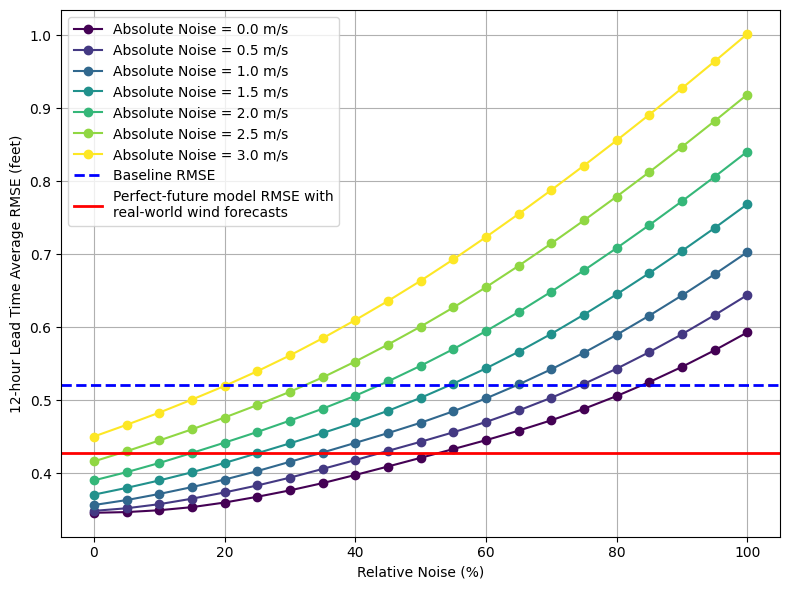

In [9]:
plt.figure(figsize=(8, 6))
cmap = plt.get_cmap('viridis', len(abs_levels))
colors = [cmap(i) for i in range(len(abs_levels))]

for i, abs_std in enumerate(abs_levels):
    rels = [item[1] for item in rmse_lst if item[0] == abs_std]
    rmses = [item[2] for item in rmse_lst if item[0] == abs_std]
    plt.plot(np.array(rels)*100, rmses, color=colors[i], marker='o', label=f'Absolute Noise = {abs_std:.1f} m/s')

plt.axhline(y=rmse_base, color='b', linestyle='--', linewidth=2, label='Baseline RMSE')
plt.axhline(y=rmse_fcst, color='r', linewidth=2, label='Perfect-future model RMSE with\nreal-world wind forecasts')
plt.xlabel('Relative Noise (%)')
plt.ylabel('12-hour Lead Time Average RMSE (feet)')
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.savefig('exp_1_1.png', dpi=1200, format='png')
plt.show()

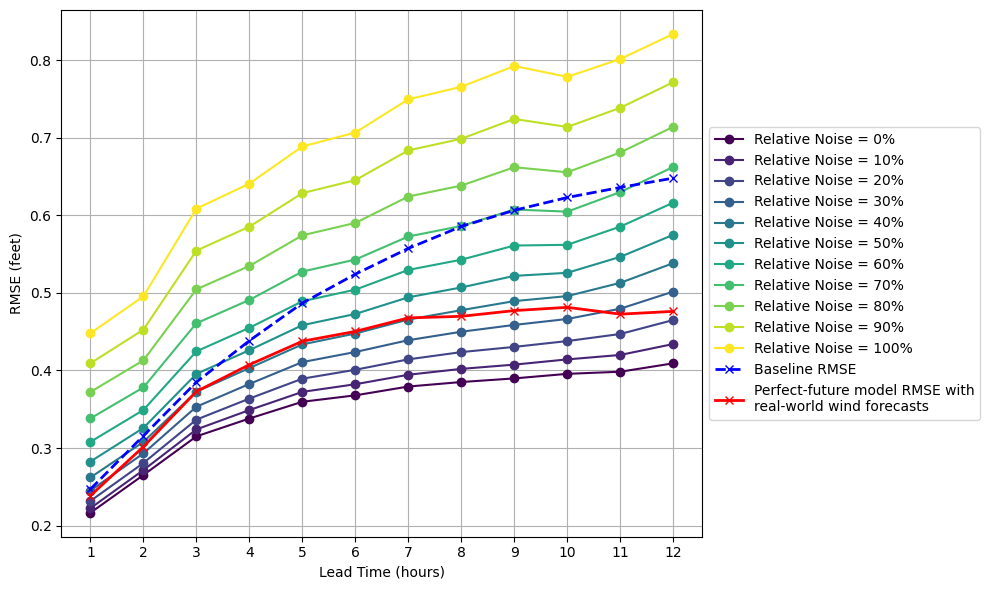

In [10]:
rmse_arr_lst = [(rel_std, arr) for rel_std, arr in rmse_arr_lst if any(np.isclose(rel_std, v, atol=1e-6) for v in np.arange(0.0, 1.01, 0.1))]

plt.figure(figsize=(10, 6))
cmap = plt.get_cmap('viridis', len(rmse_arr_lst))
colors = [cmap(i) for i in range(len(rmse_arr_lst))]

for i, (rel_std, rmse_arr) in enumerate(rmse_arr_lst):
    plt.plot(np.arange(1, 13), rmse_arr, color=colors[i], marker='o', label=f'Relative Noise = {rel_std*100:.0f}%')

plt.plot(np.arange(1, 13), rmse_arr1, color='b', linestyle='--', linewidth=2, marker='x', label='Baseline RMSE')
plt.plot(np.arange(1, 13), rmse_arr2, color='r', linewidth=2, marker='x', label='Perfect-future model RMSE with\nreal-world wind forecasts')
plt.xticks(np.arange(1, 13, 1))
plt.xlabel('Lead Time (hours)')
plt.ylabel('RMSE (feet)')
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
# plt.savefig('exp_1_2.png', dpi=1200, format='png')
plt.show()